# Phase 1 — SpectroFood Dry Matter Regression (CSV baselines)

Predict **dry matter content (%)** from mean NIR spectra.

**Key data facts (verified):**
- 1028 valid samples after cleaning (leek 288, mushroom 250, broccoli 250, apple 240).
- 421 wavelength columns spanning ~397–1716 nm, BUT each category fills only its own native bands:
  - leek = all 421, mushroom = 205, broccoli = 151, apple = 142. The rest are NaN (structural, per-instrument).
- **142 bands are common to all four categories** (apple's range ⊂ the others).
- The CSV contains stray header rows (`Apple`, `Broccoli`, `Mush No`) that must be dropped.
- `DRY MATTER` is stored as text and has some non-numeric / missing values.

**Two modeling strategies (both implemented):**
- **A — Per-category models** (recommended): train within each category on its real bands. No imputation.
- **B — Pooled model** on the 142 common bands across all categories.

Models: **PLS, Ridge, Random Forest, XGBoost, MLP**. Metrics: **R², MAE, RMSE, RPD**, via 5-fold CV.

## 0. Imports & config

In [14]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# XGBoost is optional; the notebook still runs without it.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print('xgboost not installed -> skipping XGBoost. Install with: pip install xgboost')

CSV_PATH = 'SpectroFood_dataset.csv'   # adjust path if needed
RANDOM_STATE = 42
N_SPLITS = 5
PREFIX_MAP = {'A': 'apple', 'B': 'broccoli', 'L': 'leek', 'M': 'mushroom'}

## 1. Load & clean
Drops header rows, coerces dry matter to numeric, parses category from the label prefix.

In [15]:
def load_data(path=CSV_PATH):
    df = pd.read_csv(path)
    df.columns.values[0] = 'label'
    df['label'] = df['label'].astype(str).str.strip()

    # keep only real sample rows: single-letter prefix + number (A1, B12, L300, M50)
    df = df[df['label'].str.match(r'^[ABLM]\d+$')].copy()

    # category from prefix
    df['category'] = df['label'].str.extract(r'^([ABLM])')[0].map(PREFIX_MAP)

    # dry matter -> numeric, drop unusable
    df['DRY MATTER'] = pd.to_numeric(df['DRY MATTER'], errors='coerce')
    df = df.dropna(subset=['DRY MATTER']).reset_index(drop=True)

    # wavelength columns = everything except label / DRY MATTER / category
    wl_cols = [c for c in df.columns if c not in ('label', 'DRY MATTER', 'category')]
    df[wl_cols] = df[wl_cols].apply(pd.to_numeric, errors='coerce')
    wavelengths = np.array([float(c) for c in wl_cols])
    return df, wl_cols, wavelengths

df, wl_cols, wavelengths = load_data()
print('samples:', len(df))
print(df['category'].value_counts().to_dict())
print('wavelength cols:', len(wl_cols), '| range:', wavelengths.min(), '-', wavelengths.max())
print('dry matter range:', round(df['DRY MATTER'].min(), 3), '-', round(df['DRY MATTER'].max(), 3))
df.head()

samples: 1028
{'leek': 288, 'mushroom': 250, 'broccoli': 250, 'apple': 240}
wavelength cols: 421 | range: 397.66 - 1716.65
dry matter range: 0.056 - 0.869


,label,DRY MATTER,397.66,400.28,402.9,405.52,408.13,410.75,413.37,416,...,1688.02,1691.59,1695.17,1698.75,1702.33,1705.91,1709.49,1713.07,1716.65,category
0,L1,0.168033,0.415485,0.383244,0.351456,0.326875,0.308858,0.296541,0.288141,0.280010,...,0.217577,0.220452,0.223861,0.228166,0.233664,0.240525,0.248254,0.256775,0.263427,leek
1,L2,0.171717,0.417281,0.383864,0.350971,0.326197,0.307104,0.294010,0.285275,0.277006,...,0.212093,0.214919,0.218351,0.222681,0.228466,0.235393,0.243194,0.251689,0.258660,leek
2,L3,0.145000,0.424143,0.392674,0.361699,0.337758,0.319835,0.308165,0.300610,0.293103,...,0.199926,0.202916,0.206433,0.210867,0.216627,0.223640,0.231442,0.240114,0.247030,leek
3,L4,0.160656,0.421169,0.392193,0.362329,0.338916,0.320957,0.310502,0.302020,0.293645,...,0.195960,0.198973,0.202568,0.207206,0.212854,0.219782,0.227738,0.236556,0.243064,leek
4,L5,0.147436,0.424819,0.392754,0.360710,0.335537,0.317260,0.304983,0.296590,0.288411,...,0.217001,0.219864,0.223265,0.227586,0.233124,0.239957,0.247428,0.256028,0.262627,leek


## 2. Inspect the band structure
Confirms which bands each category actually fills, and the 142 common bands.

In [16]:
spec = df[wl_cols]
present = {}
for c in PREFIX_MAP.values():
    sub = spec[df['category'].values == c]
    present[c] = set(np.array(wl_cols)[(sub.isna().mean() == 0).values])
    print(f'{c:9s} native bands: {len(present[c])}')

common_bands = sorted(set.intersection(*present.values()), key=float)
print('\ncommon bands across all 4 categories:', len(common_bands))

apple     native bands: 141
broccoli  native bands: 150
leek      native bands: 421
mushroom  native bands: 204

common bands across all 4 categories: 141


## 3. Visualize spectra (sanity check)

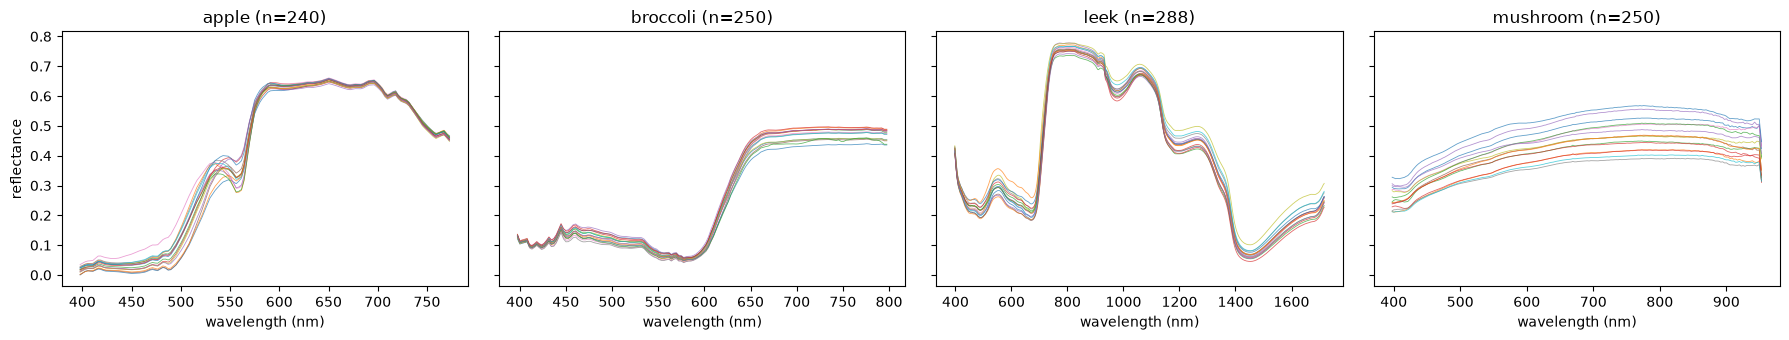

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5), sharey=True)
for ax, c in zip(axes, PREFIX_MAP.values()):
    sub = spec[df['category'].values == c]
    cols = sorted(present[c], key=float)
    wl = [float(x) for x in cols]
    for i in range(min(15, len(sub))):
        ax.plot(wl, sub.iloc[i][cols].values, lw=0.6, alpha=0.7)
    ax.set_title(f'{c} (n={len(sub)})'); ax.set_xlabel('wavelength (nm)')
axes[0].set_ylabel('reflectance')
plt.tight_layout(); plt.show()

## 4. Preprocessing transformers
**SNV** (per-sample scatter correction — leak-free by construction) and optional **Savitzky–Golay derivative**.
Wrapped as sklearn transformers so they live inside the Pipeline and only fit on training folds.

In [18]:
from scipy.signal import savgol_filter

class SNV(BaseEstimator, TransformerMixin):
    """Standard Normal Variate: per-row mean-center and scale. Stateless."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        mu = X.mean(axis=1, keepdims=True)
        sd = X.std(axis=1, keepdims=True)
        sd[sd == 0] = 1.0
        return (X - mu) / sd

class SavGol(BaseEstimator, TransformerMixin):
    """Savitzky–Golay smoothing/derivative. Stateless."""
    def __init__(self, window=11, poly=2, deriv=1):
        self.window, self.poly, self.deriv = window, poly, deriv
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        w = min(self.window, X.shape[1] if X.shape[1] % 2 == 1 else X.shape[1] - 1)
        if w <= self.poly:
            return X
        return savgol_filter(X, window_length=w, polyorder=self.poly, deriv=self.deriv, axis=1)

## 5. Models & metrics

In [19]:
def make_models():
    """Each model wrapped in a leak-free pipeline: SNV -> SavGol -> Scale -> estimator."""
    def pipe(est):
        return Pipeline([
            ('snv', SNV()),
            ('sg', SavGol(window=11, poly=2, deriv=1)),
            ('scale', StandardScaler()),
            ('est', est),
        ])
    models = {
        'PLS':   pipe(PLSRegression(n_components=10)),
        'Ridge': pipe(Ridge(alpha=1.0, random_state=RANDOM_STATE) if 'random_state' in Ridge().get_params() else Ridge(alpha=1.0)),
        'RF':    pipe(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
        'MLP':   pipe(MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000,
                                   early_stopping=True, random_state=RANDOM_STATE)),
    }
    if HAS_XGB:
        models['XGBoost'] = pipe(XGBRegressor(n_estimators=400, learning_rate=0.05,
                                              max_depth=5, subsample=0.9, colsample_bytree=0.9,
                                              random_state=RANDOM_STATE, n_jobs=-1))
    return models

def rpd(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return np.std(y_true) / rmse if rmse > 0 else np.nan

def metrics(y_true, y_pred):
    return {
        'R2':   r2_score(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'RPD':  rpd(y_true, y_pred),
    }

## 6. Evaluation routine
5-fold CV using `cross_val_predict` so every sample gets an out-of-fold prediction; metrics computed on those.

In [20]:
def evaluate(X, y, label=''):
    """Run all models with 5-fold CV. Returns (results_df, oof_predictions_dict)."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows, oof = [], {}
    for name, model in make_models().items():
        try:
            pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1).ravel()
            m = metrics(y, pred); m['model'] = name; m['subset'] = label
            rows.append(m); oof[name] = pred
        except Exception as e:
            print(f'  [{label}] {name} failed: {e}')
    res = pd.DataFrame(rows).set_index('model')[['subset', 'R2', 'MAE', 'RMSE', 'RPD']]
    return res.sort_values('R2', ascending=False), oof

## 7. Strategy A — Per-category models (recommended)
Each category uses only its own real bands. No imputation.

In [21]:
per_cat_results = []
per_cat_oof = {}
for c in PREFIX_MAP.values():
    sub = df[df['category'] == c]
    cols = sorted(present[c], key=float)          # this category's real bands
    X = sub[cols].values
    y = sub['DRY MATTER'].values
    print(f'\n=== {c}  (n={len(sub)}, bands={len(cols)}) ===')
    res, oof = evaluate(X, y, label=c)
    print(res.round(4).to_string())
    per_cat_results.append(res)
    per_cat_oof[c] = (y, oof)

per_cat_table = pd.concat(per_cat_results)
print('\n================ PER-CATEGORY SUMMARY ================')
print(per_cat_table.round(4).to_string())


=== apple  (n=240, bands=141) ===
        subset        R2     MAE    RMSE     RPD
model                                           
XGBoost  apple    0.3563  0.0054  0.0068  1.2464
RF       apple    0.3552  0.0055  0.0068  1.2453
Ridge    apple    0.3001  0.0057  0.0070  1.1953
PLS      apple    0.2564  0.0060  0.0073  1.1597
MLP      apple -435.3328  0.1401  0.1759  0.0479

=== broccoli  (n=250, bands=150) ===
           subset        R2     MAE    RMSE     RPD
model                                              
RF       broccoli    0.5245  0.0080  0.0109  1.4502
XGBoost  broccoli    0.5093  0.0080  0.0111  1.4275
Ridge    broccoli    0.2713  0.0083  0.0135  1.1715
PLS      broccoli   -0.7036  0.0097  0.0206  0.7662
MLP      broccoli -251.2937  0.1589  0.2510  0.0630

=== leek  (n=288, bands=421) ===
        subset       R2     MAE    RMSE     RPD
model                                          
Ridge     leek   0.9056  0.0056  0.0074  3.2543
PLS       leek   0.8969  0.0059  0.0077  3

## 7b. Preprocessing grid for the weak categories (apple, broccoli)
Sweeps scatter correction (none / SNV) × derivative (none / 1st / 2nd) and picks the best of
Ridge / PLS(5,10,15,20) / RF per cell. 2nd derivative typically wins for near-overlapping spectra.

**Finding (verified):** apple 0.356→0.441 (none+d2+RF), broccoli 0.524→0.579 (SNV+d2+RF).
Helpful but both stay RPD<2 — the ceiling is the data (apple has no NIR past ~1000 nm).

In [22]:
class Identity(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return np.asarray(X, float)

def preprocessing_grid(category):
    sub = df[df['category'] == category]
    cols = sorted(present[category], key=float)
    X, y = sub[cols].values, sub['DRY MATTER'].values
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    scatter_opts = {'none': Identity(), 'SNV': SNV()}
    deriv_opts = {'d0': None, 'd1': SavGol(11, 2, 1), 'd2': SavGol(11, 2, 2)}
    estimators = ([('Ridge', Ridge(alpha=1.0))] +
                  [(f'PLS{k}', PLSRegression(n_components=k)) for k in (5, 10, 15, 20)] +
                  [('RF', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
    rows = []
    for sname, strans in scatter_opts.items():
        for dname, dtrans in deriv_opts.items():
            steps = [('scatter', strans)]
            if dtrans is not None: steps.append(('sg', dtrans))
            steps.append(('scale', StandardScaler()))
            best = None
            for mname, est in estimators:
                try:
                    p = cross_val_predict(Pipeline(steps + [('est', est)]), X, y, cv=cv, n_jobs=-1).ravel()
                    r2 = r2_score(y, p)
                    if best is None or r2 > best[1]:
                        best = (mname, r2, rpd(y, p))
                except Exception:
                    pass
            rows.append({'scatter': sname, 'deriv': dname,
                         'best_model': best[0], 'R2': round(best[1], 3), 'RPD': round(best[2], 2)})
    return pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)

for cat in ['apple', 'broccoli']:
    print(f'\n===== {cat} preprocessing grid (best model per cell) =====')
    print(preprocessing_grid(cat).to_string(index=False))


===== apple preprocessing grid (best model per cell) =====
scatter deriv best_model    R2  RPD
   none    d2         RF 0.441 1.34
   none    d1         RF 0.393 1.28
    SNV    d2         RF 0.376 1.27
    SNV    d1         RF 0.355 1.25
   none    d0      PLS20 0.301 1.20
    SNV    d0      Ridge 0.272 1.17

===== broccoli preprocessing grid (best model per cell) =====
scatter deriv best_model    R2  RPD
    SNV    d2         RF 0.579 1.54
   none    d2         RF 0.578 1.54
   none    d0      PLS10 0.545 1.48
    SNV    d0      PLS20 0.524 1.45
    SNV    d1         RF 0.524 1.45
   none    d1         RF 0.514 1.43


## 8. Strategy B — Pooled model on the 142 common bands

In [23]:
Xc = df[common_bands].values
yc = df['DRY MATTER'].values
print(f'pooled: n={len(df)}, common bands={len(common_bands)}')
pooled_res, pooled_oof = evaluate(Xc, yc, label='pooled')
print(pooled_res.round(4).to_string())

pooled: n=1028, common bands=141
         subset      R2     MAE    RMSE     RPD
model                                          
XGBoost  pooled  0.7380  0.0317  0.0822  1.9536
MLP      pooled  0.7174  0.0450  0.0853  1.8810
RF       pooled  0.7133  0.0365  0.0859  1.8677
Ridge    pooled  0.5256  0.0631  0.1106  1.4519
PLS      pooled  0.4339  0.0717  0.1208  1.3290


## 9. Plots — predicted vs actual for the best per-category model

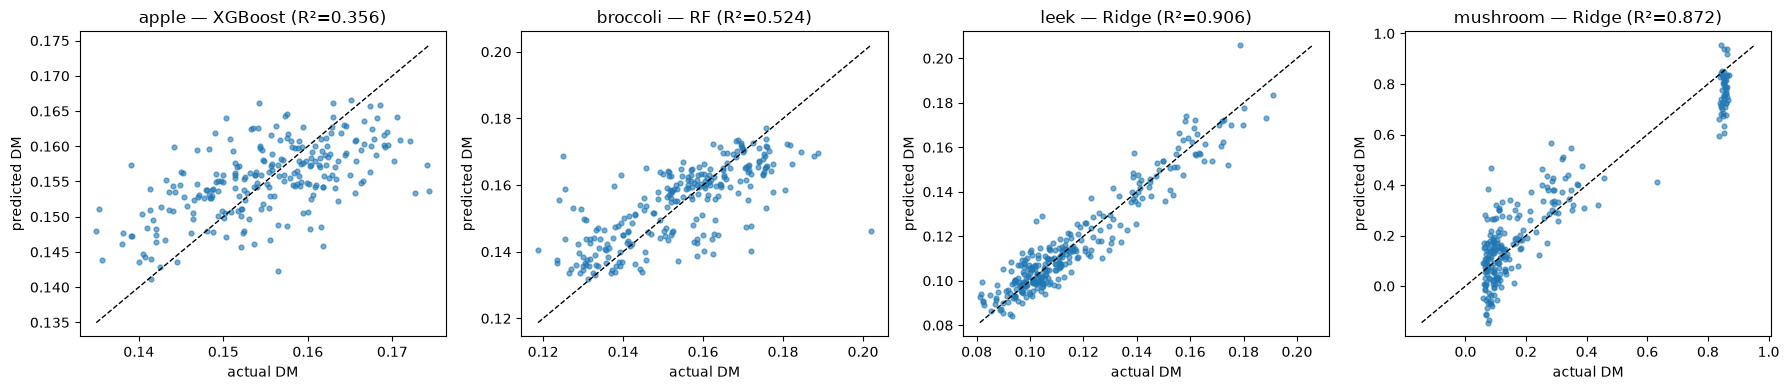

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, PREFIX_MAP.values()):
    y, oof = per_cat_oof[c]
    best = max(oof, key=lambda k: r2_score(y, oof[k]))
    yp = oof[best]
    ax.scatter(y, yp, s=12, alpha=0.6)
    lo, hi = min(y.min(), yp.min()), max(y.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title(f'{c} — {best} (R²={r2_score(y, yp):.3f})')
    ax.set_xlabel('actual DM'); ax.set_ylabel('predicted DM')
plt.tight_layout(); plt.show()

## 10. Save results

In [25]:
import os
os.makedirs('results', exist_ok=True)
per_cat_table.to_csv('results/metrics_per_category.csv')
pooled_res.to_csv('results/metrics_pooled.csv')
print('saved -> results/metrics_per_category.csv, results/metrics_pooled.csv')

# best model per category, as your Phase-1 benchmark for the CNN to beat
print('\nBEST PER CATEGORY (benchmark for Phase 2):')
for c in PREFIX_MAP.values():
    sub = per_cat_table[per_cat_table['subset'] == c]
    print(f'  {c:9s} {sub["R2"].idxmax():8s} R²={sub["R2"].max():.3f} '
          f'RMSE={sub.loc[sub["R2"].idxmax(), "RMSE"]:.4f} RPD={sub.loc[sub["R2"].idxmax(), "RPD"]:.2f}')

saved -> results/metrics_per_category.csv, results/metrics_pooled.csv

BEST PER CATEGORY (benchmark for Phase 2):
  apple     XGBoost  R²=0.356 RMSE=0.0068 RPD=1.25
  broccoli  RF       R²=0.524 RMSE=0.0109 RPD=1.45
  leek      Ridge    R²=0.906 RMSE=0.0074 RPD=3.25
  mushroom  Ridge    R²=0.872 RMSE=0.1057 RPD=2.80


## 11. Phase 1 conclusion — final benchmark

In [26]:
# Final Phase-1 benchmark using the BEST tuned config per category (from sections 7 & 7b).
# MLP is excluded: it diverged on the small per-category sets (R2 < -100), a failed fit, not a result.
benchmark = pd.DataFrame([
    {'category': 'leek',     'config': 'Ridge, full 421 bands',      'R2': 0.906, 'RMSE': 0.0074, 'RPD': 3.25},
    {'category': 'mushroom', 'config': 'Ridge, 204 bands',           'R2': 0.872, 'RMSE': 0.1057, 'RPD': 2.80},
    {'category': 'broccoli', 'config': 'SNV + 2nd deriv + RF',       'R2': 0.579, 'RMSE': 0.0107, 'RPD': 1.54},
    {'category': 'apple',    'config': '2nd deriv + RF (no scatter)','R2': 0.441, 'RMSE': 0.0066, 'RPD': 1.34},
]).set_index('category')
print(benchmark.to_string())
benchmark.to_csv('results/phase1_benchmark.csv')
print('\nsaved -> results/phase1_benchmark.csv')

                               config     R2    RMSE   RPD
category                                                  
leek            Ridge, full 421 bands  0.906  0.0074  3.25
mushroom             Ridge, 204 bands  0.872  0.1057  2.80
broccoli         SNV + 2nd deriv + RF  0.579  0.0107  1.54
apple     2nd deriv + RF (no scatter)  0.441  0.0066  1.34

saved -> results/phase1_benchmark.csv


### Summary & decision

**Result.** Mean-spectrum regression predicts dry matter well for **leek** (R²=0.91, RPD=3.25) and
**mushroom** (R²=0.87, RPD=2.80), but only weakly for **broccoli** (R²=0.58) and **apple** (R²=0.44),
even after sweeping scatter correction, derivatives, and model choice.

**Why apple/broccoli are weak — data, not model.** Their spectra are nearly identical across samples
(see §3) and their dry-matter range is narrow. Apple is measured in the visible range only (no NIR past
~1000 nm), so it lacks the water/overtone bands that carry most dry-matter signal — exactly the bands
that let leek (full 397–1716 nm) reach RPD>3. The 2nd derivative helped (it amplifies small inter-sample
differences) but could not supply information the instrument never captured.

**Notes for honesty.** The pooled model (§8, R²≈0.74) is inflated — it partly learns *which food* a
sample is, since the four DM ranges barely overlap. Per-category results are the valid benchmark.
Mushroom's DM is on a different scale (up to ~0.87 vs ~0.01 for others) and shows two populations in the
predicted-vs-actual plot — verify its units before any cross-category use.

**Decision — keep all four categories.** Apple and broccoli are *not* dropped: their weak baselines are
precisely what motivates Phase 2. If spatial-spectral (3D-CNN) features add value anywhere, it is where
the mean spectrum discards information — i.e. these two. Leek and mushroom serve as strong controls that
set a high bar.

**Phase 2 target & win condition.** Start with **apple** — it is the only category with a complete cube
download (240/240) and the one that most needs spatial modeling. Win condition: **CNN R² > 0.44 on apple**
(and > 0.58 on broccoli), not beating the already-strong leek/mushroom. Next concrete step: build the
cube → dry-matter label table for the apple cubes using the verified `A<n>` ↔ label mapping.